# 0 — Assessment data, research findings, live in a notebook

**The "wow" opener.** Some of the most influential findings in education research were built from exactly the kind of seasonal assessment exports you already work with—fall, winter, and spring results for the same students, year after year.

In this notebook we reproduce that literature's most famous figure **live**, from about twenty lines of plain Python, with no student data at all—just stylized parameters reported in the published studies.

The point for this session: *the same notebook stack can take your local assessment CSVs all the way to research-grade questions and publication-quality visuals.*

## The research this kind of data supports

A short tour of landmark studies built on seasonal student assessment data:

- **Heyns, B. (1978). *Summer Learning and the Effects of Schooling*. Academic Press.** The first large-scale evidence that students' achievement growth differs between the school year and summer vacation. [Search](https://scholar.google.com/scholar?q=Heyns+Summer+Learning+and+the+Effects+of+Schooling)
- **Cooper, H., Nye, B., Charlton, K., Lindsay, J., & Greathouse, S. (1996). "The Effects of Summer Vacation on Achievement Test Scores: A Narrative and Meta-Analytic Review." *Review of Educational Research*, 66(3).** A meta-analysis of 39 studies confirming seasonal differences in learning. [Search](https://scholar.google.com/scholar?q=Cooper+effects+of+summer+vacation+on+achievement+test+scores)
- **Alexander, K. L., Entwisle, D. R., & Olson, L. S. (2001). "Schools, Achievement, and Inequality: A Seasonal Perspective." *American Educational Research Journal*, 38(1).** The Baltimore Beginning School Study followed one cohort across K–9 and found that most of the widening socioeconomic reading gap accumulated **over the summers**, not during school years. [Search](https://scholar.google.com/scholar?q=Alexander+Entwisle+Olson+Schools+Achievement+and+Inequality+Seasonal+Perspective)
- **Downey, D. B., von Hippel, P. T., & Broh, B. A. (2004). "Are Schools the Great Equalizer? Cognitive Inequality during Summer Months and the School Year." *AERJ*, 41(3).** Asked directly whether school-year learning narrows gaps that summers widen. [Search](https://scholar.google.com/scholar?q=Downey+von+Hippel+Broh+Are+Schools+the+Great+Equalizer)

These studies needed no exotic data—just repeated, comparable scores for the same students at known times of year. That is what a test vendor export gives you.

## Reproducing the headline finding — live

Below, we generate stylized trajectories using parameters drawn from the published findings above and plot them with plain `matplotlib`:

- Students start kindergarten at the same reading level.
- **Both groups gain similarly during the school year** (schools as "equalizers").
- **The higher-SES group holds or gains ground over each summer, while the lower-SES group loses ground.**

This is our own code and our own figure, created for illustration—it is *not* a copy of any published figure, and the parameters are simplified for the demo.

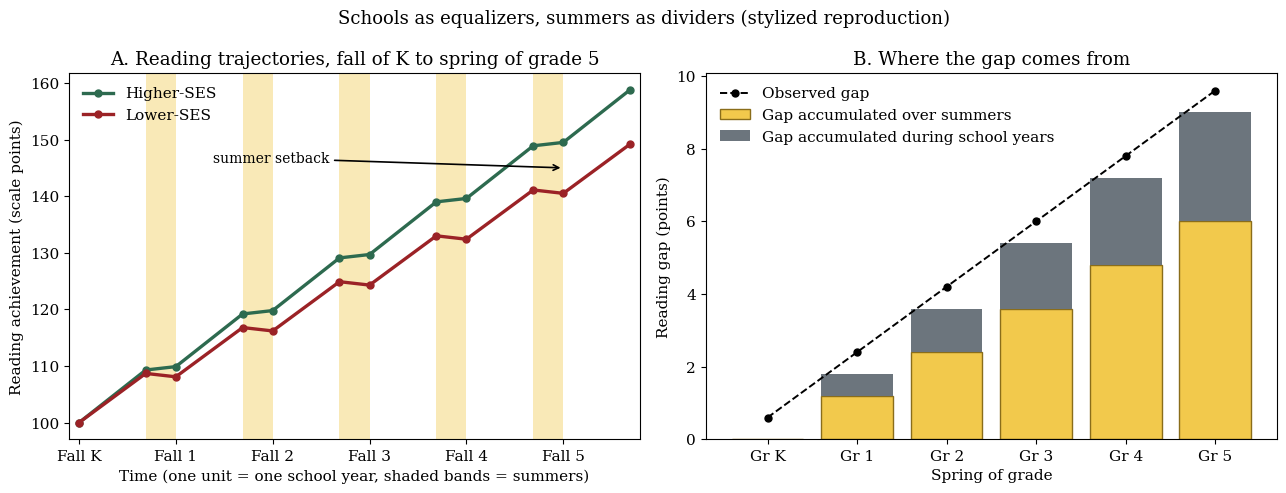

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Stylized parameters chosen to echo the published findings above.
GRADES = ["K", "1", "2", "3", "4", "5"]
START = 100.0
SCHOOL_GAIN = {"Higher-SES": 9.3, "Lower-SES": 8.7}   # per school year
SUMMER_CHANGE = {"Higher-SES": 0.6, "Lower-SES": -0.6}  # per summer
SUMMER_UNITS = 0.45                                   # summer length on the time axis

def stylized_trajectories():
    """Fall-of-K to spring-of-grade-5 reading trajectories for two SES groups."""
    t = [0.0]
    hi = [START]
    lo = [START]
    for grade in GRADES:
        for group, series in (("Higher-SES", hi), ("Lower-SES", lo)):
            series.append(series[-1] + SCHOOL_GAIN[group])
        t.append(t[-1] + 1.0)  # school year
        if grade != "5":
            for group, series in (("Higher-SES", hi), ("Lower-SES", lo)):
                series.append(series[-1] + SUMMER_CHANGE[group])
            t.append(t[-1] + SUMMER_UNITS)  # summer
    return np.array(t), np.array(hi), np.array(lo)

t, hi, lo = stylized_trajectories()
spring_idx = [1, 3, 5, 7, 9, 11]
summer_widening = np.array([1.2 * n for n in range(6)])   # gap added each summer, cumulative
school_widening = np.array([0.6 * n for n in range(6)])    # gap added each school year
gap_at_spring = (hi - lo)[spring_idx]

# Journal-style presentation: serif fonts, labeled panels, a shaded "summer" band.
plt.rcParams.update({"font.family": "serif", "font.size": 11})
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for spring_end in t[spring_idx[:-1]]:
    ax.axvspan(spring_end, spring_end + SUMMER_UNITS, color="#f2c94c", alpha=0.4, lw=0)
ax.plot(t, hi, "-o", color="#2d6a4f", lw=2.4, ms=5, label="Higher-SES")
ax.plot(t, lo, "-o", color="#9b2226", lw=2.4, ms=5, label="Lower-SES")
ax.annotate(
    "summer setback",
    xy=(t[10], (hi[10] + lo[10]) / 2),
    xytext=(2.0, 146),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10,
)
fall_positions = [0.0] + [t[i] for i in (2, 4, 6, 8, 10)]
ax.set(
    title="A. Reading trajectories, fall of K to spring of grade 5",
    xlabel="Time (one unit = one school year, shaded bands = summers)",
    ylabel="Reading achievement (scale points)",
    xticks=fall_positions,
    xticklabels=[f"Fall {g}" for g in GRADES],
    xlim=(-0.15, t[-1] + 0.15),
)
ax.legend(frameon=False, loc="upper left")

ax = axes[1]
years = np.arange(6)
ax.bar(
    years,
    summer_widening,
    color="#f2c94c",
    edgecolor="#8a6d1a",
    label="Gap accumulated over summers",
)
ax.bar(
    years,
    school_widening,
    bottom=summer_widening,
    color="#6c757d",
    label="Gap accumulated during school years",
)
ax.plot(years, gap_at_spring, "k--o", lw=1.4, ms=5, label="Observed gap")
ax.set(
    title="B. Where the gap comes from",
    xlabel="Spring of grade",
    ylabel="Reading gap (points)",
    xticks=years,
    xticklabels=[f"Gr {g}" for g in GRADES],
)
ax.legend(frameon=False)

fig.suptitle(
    "Schools as equalizers, summers as dividers (stylized reproduction)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### What the panel shows

- **Panel A:** the two groups' in-school gains are nearly parallel—while school is in session, everyone grows at almost the same rate. The divergence happens almost entirely across the shaded **summer bands**.
- **Panel B:** decomposing the gap at each spring: in this stylized model about **two-thirds of the widening** is attributable to summers, echoing what Alexander, Entwisle & Olson (2001) found in their longitudinal cohort.

For a live audience, this framing lands well: *your district's fall/winter/spring exports contain exactly the ingredients these studies were built from—repeated, comparable, within-student measurements.*

All of this came from plain Python in a notebook. Now let's make it move.

## Watch the gap accumulate, summer by summer

In [3]:
import numpy as np
from IPython.display import HTML, Markdown, display
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.set(
    xlabel="Time (one unit = one school year, shaded bands = summers)",
    ylabel="Reading achievement (scale points)",
    xticks=fall_positions,
    xticklabels=[f"Fall {g}" for g in GRADES],
    xlim=(-0.15, t[-1] + 0.15),
    ylim=(98, 162),
)

def draw_frame(stop_idx):
    ax.clear()
    for spring_end in t[spring_idx[:-1]][: stop_idx // 2]:
        ax.axvspan(spring_end, spring_end + SUMMER_UNITS, color="#f2c94c", alpha=0.4, lw=0)
    ax.plot(t[: stop_idx + 1], hi[: stop_idx + 1], "-o", color="#2d6a4f", lw=2.4, ms=5)
    ax.plot(t[: stop_idx + 1], lo[: stop_idx + 1], "-o", color="#9b2226", lw=2.4, ms=5)
    if stop_idx in spring_idx:
        grade = GRADES[spring_idx.index(stop_idx)]
        gap = hi[stop_idx] - lo[stop_idx]
        ax.text(
            0.02,
            0.95,
            f"Spring of grade {grade}:  gap = {gap:.1f} points",
            transform=ax.transAxes,
            fontsize=12,
            va="top",
            bbox=dict(boxstyle="round", fc="white", ec="#999999"),
        )
    elif stop_idx == 0:
        ax.text(
            0.02,
            0.95,
            "Fall of kindergarten: everyone starts in the same place",
            transform=ax.transAxes,
            fontsize=12,
            va="top",
            bbox=dict(boxstyle="round", fc="white", ec="#999999"),
        )
    else:
        ax.text(
            0.02,
            0.95,
            "Over the summer... the gap widens",
            transform=ax.transAxes,
            fontsize=12,
            va="top",
            bbox=dict(boxstyle="round", fc="white", ec="#999999"),
        )
    ax.set(
        xlabel="Time (one unit = one school year, shaded bands = summers)",
        ylabel="Reading achievement (scale points)",
        xticks=fall_positions,
        xticklabels=[f"Fall {g}" for g in GRADES],
        xlim=(-0.15, t[-1] + 0.15),
        ylim=(98, 162),
    )

animation = FuncAnimation(
    fig, draw_frame, frames=range(len(t)), interval=900, repeat=True, blit=False
)
plt.close(fig)  # keep the inline figure area clean; the player below shows the animation
HTML(animation.to_jshtml())

## Make it yourself: drag the sliders

Jupyter is not just a document—it is an **interactive environment**. This next cell (which runs live in Jupyter Lab) lets you change the summer setback parameters and watch the trajectories respond in real time.

This is the same `matplotlib` code as before, just re-run on demand with your parameters.

In [3]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact

    def summer_setback_experiment(hi_summer=0.6, lo_summer=-0.6, lo_school_gain=8.7):
        hi_local, lo_local = [START], [START]
        t_local = [0.0]
        for grade in GRADES:
            hi_local.append(hi_local[-1] + SCHOOL_GAIN["Higher-SES"])
            lo_local.append(lo_local[-1] + lo_school_gain)
            t_local.append(t_local[-1] + 1.0)
            if grade != "5":
                hi_local.append(hi_local[-1] + hi_summer)
                lo_local.append(lo_local[-1] + lo_summer)
                t_local.append(t_local[-1] + SUMMER_UNITS)
        t_arr = np.array(t_local)
        fig, ax = plt.subplots(figsize=(8.5, 5))
        for spring_end in t_arr[spring_idx[:-1]]:
            ax.axvspan(spring_end, spring_end + SUMMER_UNITS, color="#f2c94c", alpha=0.4, lw=0)
        ax.plot(t_arr, hi_local, "-o", color="#2d6a4f", lw=2.4, ms=5, label="Higher-SES")
        ax.plot(t_arr, lo_local, "-o", color="#9b2226", lw=2.4, ms=5, label="Lower-SES")
        final_gap = hi_local[-1] - lo_local[-1]
        ax.set(
            title=f"Spring grade 5 gap: {final_gap:.1f} points",
            xlabel="Time (one unit = one school year, shaded bands = summers)",
            ylabel="Reading achievement (scale points)",
            xticks=fall_positions,
            xticklabels=[f"Fall {g}" for g in GRADES],
            xlim=(-0.15, t_arr[-1] + 0.15),
        )
        ax.legend(frameon=False, loc="upper left")
        plt.tight_layout()
        plt.show()

    interact(
        summer_setback_experiment,
        hi_summer=widgets.FloatSlider(min=-2.0, max=3.0, step=0.1, value=0.6,
                                      description="Higher-SES summer"),
        lo_summer=widgets.FloatSlider(min=-4.0, max=1.0, step=0.1, value=-0.6,
                                      description="Lower-SES summer"),
        lo_school_gain=widgets.FloatSlider(min=6.0, max=11.0, step=0.1, value=8.7,
                                           description="Lower-SES school gain"),
    )
except ImportError:
    display(Markdown(
        "Install `ipywidgets` to make this cell interactive: "
        "`pip install ipywidgets` (the static figure above still tells the story)."
    ))

interactive(children=(FloatSlider(value=0.6, description='Higher-SES summer', max=3.0, min=-2.0), FloatSlider(…

### The takeaway for this session

- That entire sequence—narrative, citations, data generation, publication-quality figure, an animation, and an interactive widget—lives in **one reproducible, shareable document**.
- It used **no student data at all**. Everything was synthetic parameters and plain Python.
- The same stack—`pandas` + `matplotlib`/`seaborn` in Jupyter—is what the rest of this demo applies to real assessment exports, **locally, on your machine**.

Next up: **`01_local_first_look.ipynb`** opens the assessment CSVs and shows the data never has to leave this notebook.